#### Árboles de regresión 

##### 0 Cargar paqueterías

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from ydata_profiling import ProfileReport

##### 1 Cargas la base de datos y quedarnos con las variables que nos interesan

In [2]:
df = pd.read_csv("ToyotaCorolla.csv")

car_df = df[['price', 'age_08_04', 'km', 'fuel_type',
             'hp', 'met_color', 'automatic', 'cc', 'doors',
             'quarterly_tax', 'weight']].copy()

print(car_df.info())
car_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   price          1436 non-null   int64 
 1   age_08_04      1436 non-null   int64 
 2   km             1436 non-null   int64 
 3   fuel_type      1436 non-null   object
 4   hp             1436 non-null   int64 
 5   met_color      1436 non-null   int64 
 6   automatic      1436 non-null   int64 
 7   cc             1436 non-null   int64 
 8   doors          1436 non-null   int64 
 9   quarterly_tax  1436 non-null   int64 
 10  weight         1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None


,price,age_08_04,km,fuel_type,hp,met_color,automatic,cc,doors,quarterly_tax,weight
0,13500,23,46986,Diesel,90,1,0,2000,3,210,1165
1,13750,23,72937,Diesel,90,1,0,2000,3,210,1165
2,13950,24,41711,Diesel,90,1,0,2000,3,210,1165
3,14950,26,48000,Diesel,90,0,0,2000,3,210,1165
4,13750,30,38500,Diesel,90,0,0,2000,3,210,1170


##### 2 Hacemos un reporte de la base de datos y limpiamos lo que se pueda antes de hacer el split

In [3]:
# Realiza un reporte automatizado utilizando ydata-profiling para conocer mejor el dataset. 
profile = ProfileReport(car_df, title="Toyota Corolla Dataset Report")
profile.to_file("toyota_corolla_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 48.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
# Eliminamos los duplicados
car_df = car_df.drop_duplicates()
# Transformamos la variable fuel_type en variables dicotómicas con ceros y unos
car_df = pd.get_dummies(
    car_df,
    columns=['fuel_type'],
    drop_first=True,
    dtype=int
)
car_df.head()

,price,age_08_04,km,hp,met_color,automatic,cc,doors,quarterly_tax,weight,fuel_type_Diesel,fuel_type_Petrol
0,13500,23,46986,90,1,0,2000,3,210,1165,1,0
1,13750,23,72937,90,1,0,2000,3,210,1165,1,0
2,13950,24,41711,90,1,0,2000,3,210,1165,1,0
3,14950,26,48000,90,0,0,2000,3,210,1165,1,0
4,13750,30,38500,90,0,0,2000,3,210,1170,1,0


##### 3 Split en Train/Test y limpiar después de hacer el split

In [4]:
X = car_df.drop(columns="price")
y = car_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1148, 11), (287, 11), (1148,), (287,))

In [5]:
# Aplicamos wenserización para tratar los outliers conjunto de entrenamiento
for col in ['age_08_04', 'km', 'hp', 'cc', 'quarterly_tax', 'weight']:
    X_train[col] = X_train[col].clip(lower=X_train[col].quantile(0.01), upper=X_train[col].quantile(0.99))
# Aplicamos wenserización para tratar los outliers de price
y_train = y_train.clip(lower=y_train.quantile(0.01), upper=y_train.quantile(0.99))

/tmp/ipykernel_2458/1200874144.py:3: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[col] = X_train[col].clip(lower=X_train[col].quantile(0.01), upper=X_train[col].quantile(0.99))


In [6]:
# Duplicados en X_train
duplicados_X_train = X_train.duplicated().sum()
print(f"Número de filas duplicadas en X_train: {duplicados_X_train}")
# Borramos los duplicados en X_train
X_train = X_train.drop_duplicates()
y_train = y_train.loc[X_train.index]  # Aseguramos que y_train se alinee con X_train después de eliminar duplicados
print(f"Número de filas después de eliminar duplicados en X_train: {X_train.shape[0]}")

Número de filas duplicadas en X_train: 2
Número de filas después de eliminar duplicados en X_train: 1146


##### 4 Modelo base: Árbol de regresión (sin poda todavía)

In [7]:
baseline_model = DecisionTreeRegressor(random_state=42)

baseline_pipe = Pipeline(steps=[
    ("model", baseline_model)
])

baseline_pipe.fit(X_train, y_train)

y_pred_test = baseline_pipe.predict(X_test)

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)  # (tu estándar preferido)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"BASELINE (Test) -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")

BASELINE (Test) -> RMSE: 1412.30 | MAE: 1047.81 | R2: 0.8337


In [8]:
%matplotlib inline

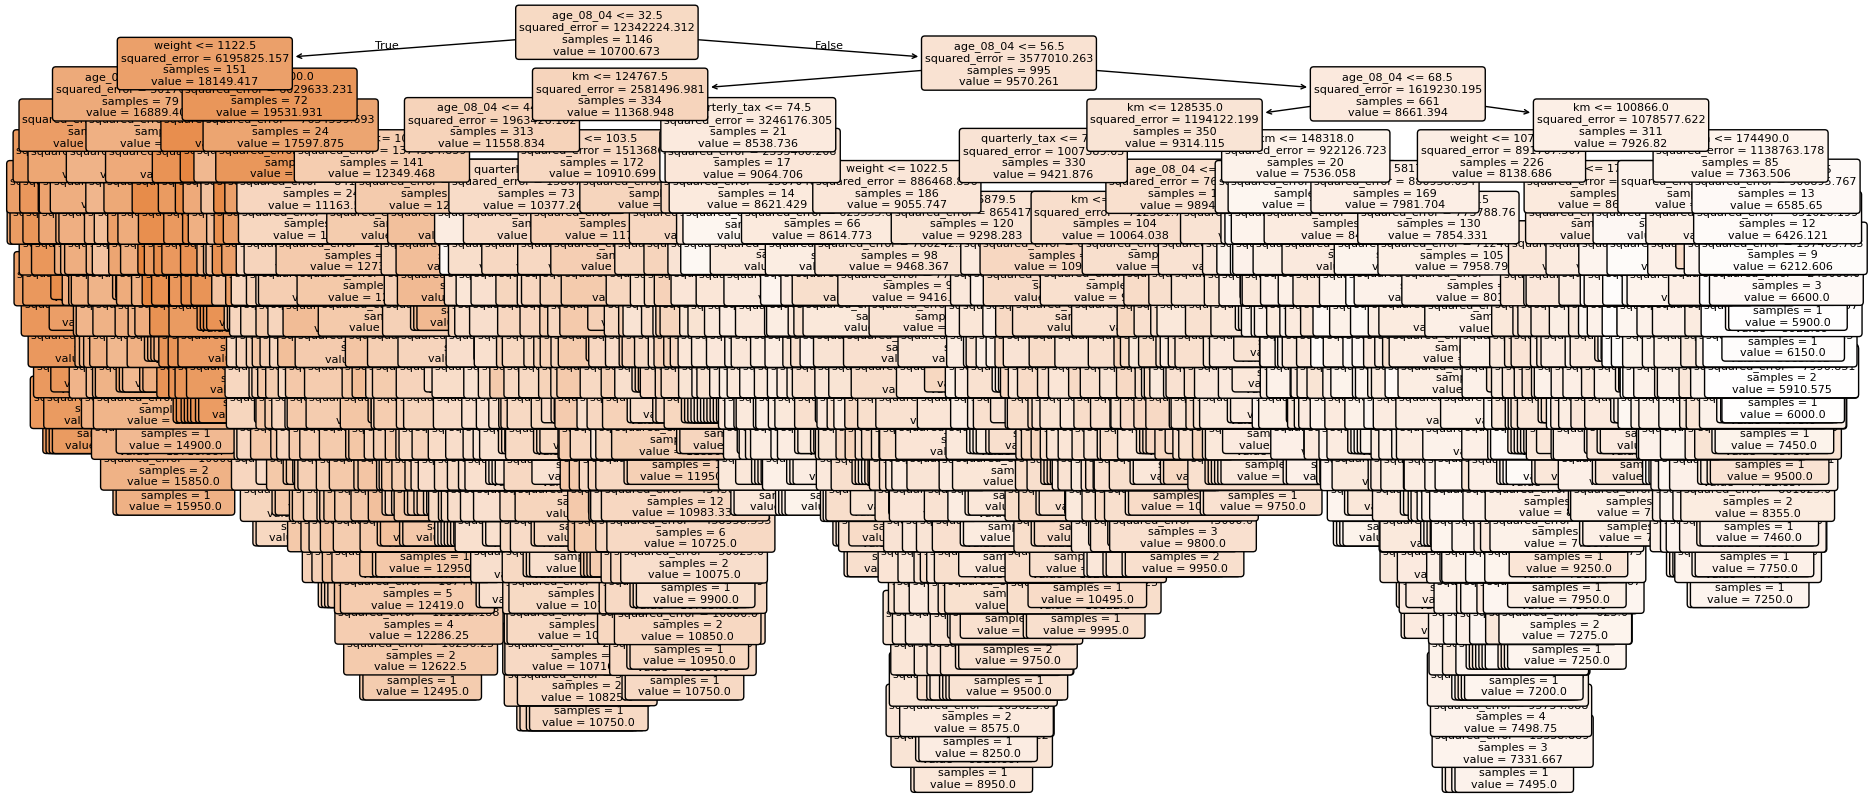

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extraer el árbol del pipeline
tree_model = baseline_pipe.named_steps["model"]

# Nombres de las variables
feature_names = X_train.columns

# Graficar el árbol
plt.figure(figsize=(22,10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

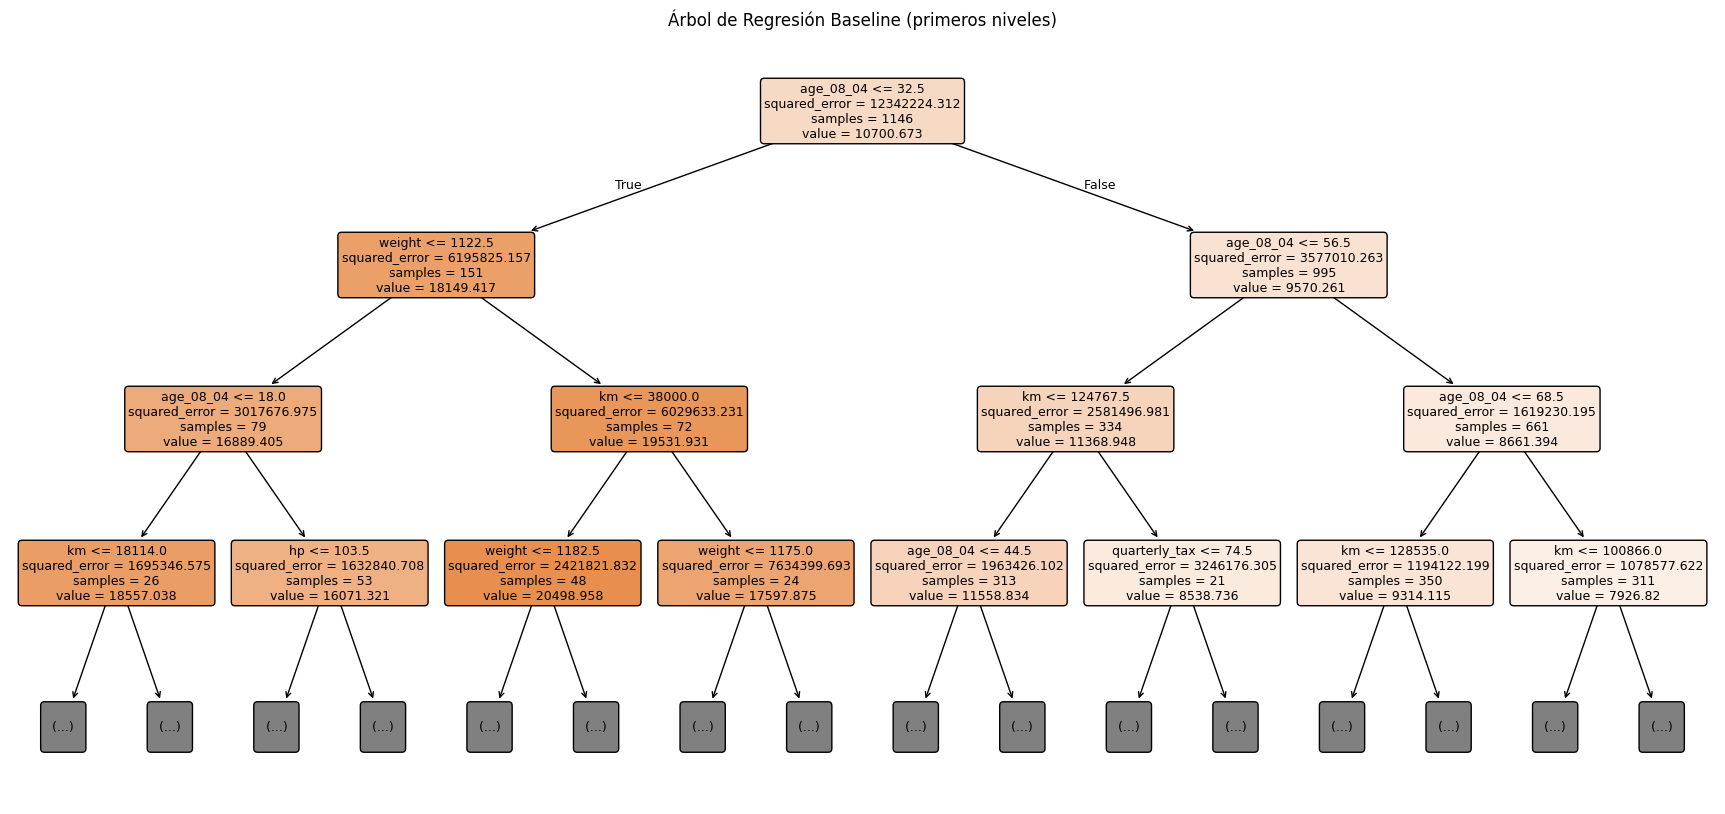

In [10]:
plt.figure(figsize=(22,10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)

plt.title("Árbol de Regresión Baseline (primeros niveles)")
plt.show()

In [11]:
from sklearn.tree import export_text

rules = export_text(
    tree_model,
    feature_names=list(feature_names)
)

print(rules[:3000])

|--- age_08_04 <= 32.50
|   |--- weight <= 1122.50
|   |   |--- age_08_04 <= 18.00
|   |   |   |--- km <= 18114.00
|   |   |   |   |--- weight <= 1102.50
|   |   |   |   |   |--- cc <= 1500.00
|   |   |   |   |   |   |--- age_08_04 <= 11.50
|   |   |   |   |   |   |   |--- value: [17795.00]
|   |   |   |   |   |   |--- age_08_04 >  11.50
|   |   |   |   |   |   |   |--- value: [16868.00]
|   |   |   |   |   |--- cc >  1500.00
|   |   |   |   |   |   |--- quarterly_tax <= 77.00
|   |   |   |   |   |   |   |--- age_08_04 <= 11.50
|   |   |   |   |   |   |   |   |--- age_08_04 <= 8.50
|   |   |   |   |   |   |   |   |   |--- value: [18500.00]
|   |   |   |   |   |   |   |   |--- age_08_04 >  8.50
|   |   |   |   |   |   |   |   |   |--- value: [18245.00]
|   |   |   |   |   |   |   |--- age_08_04 >  11.50
|   |   |   |   |   |   |   |   |--- value: [18800.00]
|   |   |   |   |   |   |--- quarterly_tax >  77.00
|   |   |   |   |   |   |   |--- value: [19500.00]
|   |   |   |   |--- weight 

##### 5 Poda del árbol (Cost-Complexity Pruning) + selección con k-folds (en train)

In [12]:
# Árbol "grande" para calcular el pruning path
tree_for_path = DecisionTreeRegressor(random_state=42)
path = tree_for_path.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
ccp_alphas = np.unique(ccp_alphas)

print("Cantidad de ccp_alphas:", len(ccp_alphas))
print("Ejemplo primeros:", ccp_alphas[:10])

Cantidad de ccp_alphas: 608
Ejemplo primeros: [0.00000000e+00 1.95041377e-11 7.27166957e-03 1.09075044e-02
 4.36300175e-02 2.72687609e-01 3.92670157e-01 6.98080279e-01
 8.83507853e-01 1.09075044e+00]


##### ¿Qué está calculando ese código?
- cost_complexity_pruning_path(): calcula todas las posibles podas del arbol usando el parámetro alpha, este paráetro controla el trade-off entre ajuste y complejidad.
Resultado
- catndiad de ccp_alphas: 608
Significa que el árbol completamente crecido tiene 608 posibles niveles de poda.
-En otras palabras:
	-	El árbol inicial es muy complejo
	-	Tiene muchísimos nodos / hojas
	-	Cada alpha corresponde a una versión más podada del árbol
El algoritmo identifica 608 puntos donde se puede simplificar el árbol.

In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

best_mae = float("inf")
best_params = None
best_model = None

for alpha in ccp_alphas:
    for leaf in [1, 3, 5, 10]:
        for depth in [None, 3, 5, 8, 12]:

            model = DecisionTreeRegressor(
                random_state=42,
                ccp_alpha=alpha,
                min_samples_leaf=leaf,
                max_depth=depth
            )

            model.fit(X_train, y_train)

            y_pred = model.predict(X_train)

            mae = mean_absolute_error(y_train, y_pred)

            if mae < best_mae:
                best_mae = mae
                best_params = {
                    "ccp_alpha": alpha,
                    "min_samples_leaf": leaf,
                    "max_depth": depth
                }
                best_model = model

print("Mejores hiperparámetros:", best_params)
print("Mejor MAE (Train):", best_mae)

Mejores hiperparámetros: {'ccp_alpha': np.float64(0.0), 'min_samples_leaf': 1, 'max_depth': None}
Mejor MAE (Train): 0.0


##### ¿Qué hace este código?    
1.	Recorre todos los valores de:
    -	ccp_alpha
    -   min_samples_leaf
    - max_depth
2.	Entrena un árbol con cada combinación.
3.	Calcula el MAE en el conjunto de entrenamiento.
4.	Guarda el modelo con menor error.

##### 6 Evaluación final del modelo con el conjunto prueba

In [14]:
y_pred_test = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"FINAL (Test) -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")

FINAL (Test) -> RMSE: 1412.30 | MAE: 1047.81 | R2: 0.8337


##### Interpretación metodológica (importante para tu práctica)

El procedimiento consiste en:
1.  Entrenar múltiples árboles variando el nivel de poda (ccp_alpha) y parámetros de complejidad.
2. Seleccionar el modelo con menor error en entrenamiento.
3. Evaluar finalmente el desempeño del modelo seleccionado en el conjunto de prueba, que permite medir su capacidad de generalización.

##### 7 K-folds en el modelo final, medida de estabilidad del modelo

In [15]:
mae_cv = -cross_val_score(best_model, X_train, y_train, scoring="neg_mean_absolute_error", cv=5, n_jobs=-1)
rmse_cv = np.sqrt(-cross_val_score(best_model, X_train, y_train, scoring="neg_mean_squared_error", cv=5, n_jobs=-1))

print("MAE CV por fold:", np.round(mae_cv, 2))
print("MAE CV promedio:", mae_cv.mean().round(2))

print("RMSE CV por fold:", np.round(rmse_cv, 2))
print("RMSE CV promedio:", rmse_cv.mean().round(2))

MAE CV por fold: [1031.95 1103.22 1053.57 1067.6  1116.24]
MAE CV promedio: 1074.52
RMSE CV por fold: [1371.04 1398.28 1358.9  1304.87 1485.81]
RMSE CV promedio: 1383.78


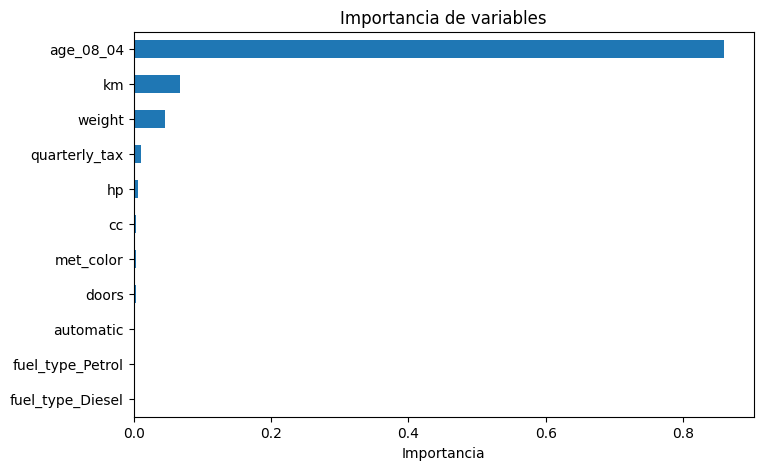

In [16]:
importancias = pd.Series(best_model.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8,5))
importancias.plot(kind='barh')
plt.title("Importancia de variables")
plt.xlabel("Importancia")
plt.show()

In [17]:
# Identificar la hoja donde cae cada cliente
leaf_id = best_model.apply(X_train)

# Crear dataset con el grupo asignado
clientes_segmentados = X_train.copy()
clientes_segmentados["grupo_arbol"] = leaf_id
clientes_segmentados["precio real"] = y_train

clientes_segmentados.head()

segmentos = clientes_segmentados.groupby("grupo_arbol").mean()
segmentos

,age_08_04,km,hp,met_color,automatic,cc,doors,quarterly_tax,weight,fuel_type_Diesel,fuel_type_Petrol,precio real
grupo_arbol,,,,,,,,,,,,
7,8.0,4470.000,98.0,1.0,0.0,1400.0,4.0,19.0,1100.0,0.0,1.0,17795.00
8,15.0,13157.000,97.0,1.0,0.0,1400.0,4.0,85.0,1085.0,0.0,1.0,16868.00
12,8.0,4470.000,110.0,0.0,0.0,1600.0,5.0,19.0,1075.0,0.0,1.0,18500.00
13,9.0,4470.000,110.0,1.0,0.0,1600.0,5.0,19.0,1075.0,0.0,1.0,18245.00
14,14.0,11500.000,110.0,1.0,0.0,1600.0,3.0,69.0,1045.0,0.0,1.0,18800.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2043,74.0,193170.250,72.0,1.0,0.0,2000.0,3.0,64.0,1135.0,1.0,0.0,5821.15
2044,78.0,193170.250,72.0,1.0,0.0,2000.0,5.0,185.0,1135.0,1.0,0.0,6000.00
2045,80.0,193170.250,72.0,0.0,0.0,2000.0,3.0,185.0,1120.0,1.0,0.0,6150.00
